In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

!pip install segmentation-models-pytorch
from segmentation_models_pytorch.losses import DiceLoss
from segmentation_models_pytorch.losses import JaccardLoss
import torch.nn.functional as F

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 6.2 MB/s eta 0:00:000:00:0100:01
  Attempting uninsta

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [18]:
# Import librerie essenziali per semantic segmentation con FCN su COCO
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models.segmentation as seg
from torchvision.models.segmentation import fcn_resnet50
import torch.nn.functional as F

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms.functional as TF
import random

from pycocotools.coco import COCO
import os
from tqdm import tqdm
import imageio.v2 as imageio

# Verifica disponibilità GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Path del subset COCO caricato su Kaggle 
ROOT_DIR = '/kaggle/input/coco-subset-complete'  
TRAIN_IMG_DIR = os.path.join(ROOT_DIR, 'train/images')
VAL_IMG_DIR = os.path.join(ROOT_DIR, 'validation/images')
TRAIN_ANN_FILE = os.path.join(ROOT_DIR, 'train/annotations.json')
VAL_ANN_FILE = os.path.join(ROOT_DIR, 'validation/annotations.json')

# Verifica che i file esistano
print(f"Train images exist: {os.path.exists(TRAIN_IMG_DIR)}")
print(f"Val images exist: {os.path.exists(VAL_IMG_DIR)}")
print(f"Train annotations exist: {os.path.exists(TRAIN_ANN_FILE)}")
print(f"Val annotations exist: {os.path.exists(VAL_ANN_FILE)}")

Train images exist: True
Val images exist: True
Train annotations exist: True
Val annotations exist: True


Caricamento annotazioni...
loading annotations into memory...
Done (t=2.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!


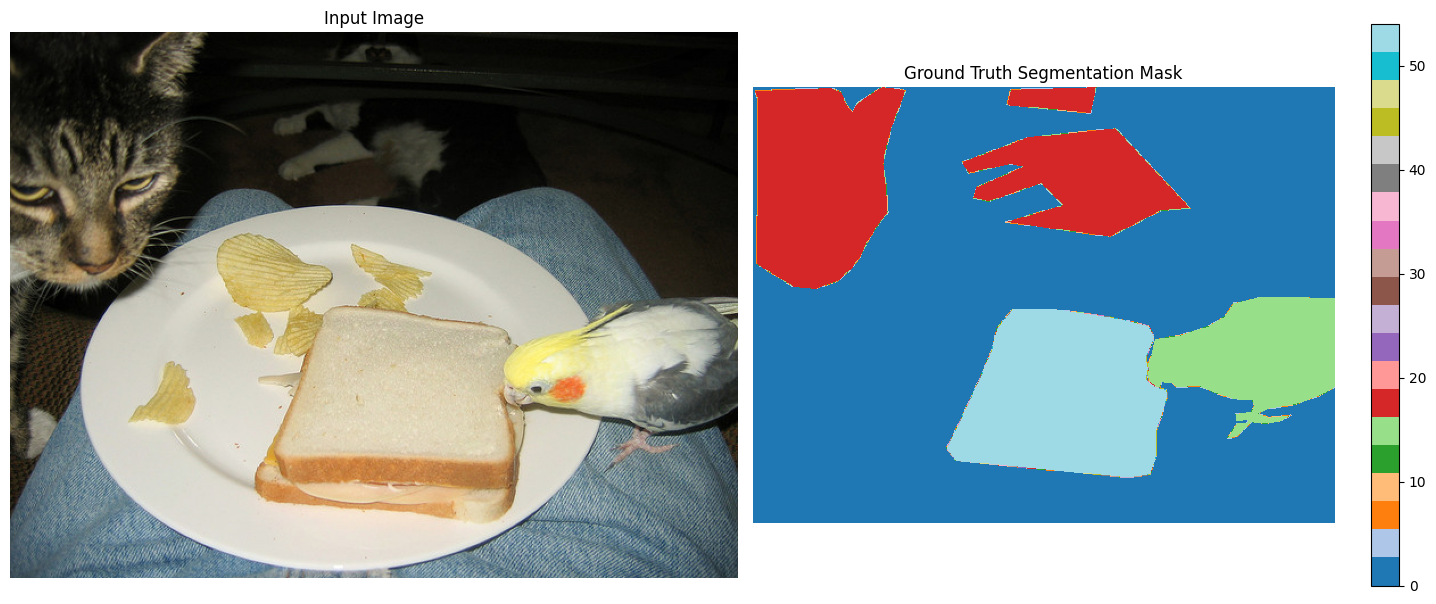

Image filename: 000000263623.jpg
Image shape: (480, 640, 3)
Mask shape: (480, 640)
Total train images in subset: 10000
Total val images in subset: 1353


In [41]:
# Visualizzazione di esempio dalle immagini del subset caricato
import imageio.v2 as imageio

# Carica annotazioni
print("Caricamento annotazioni...")
coco_train = COCO(TRAIN_ANN_FILE)
coco_val = COCO(VAL_ANN_FILE)

# Prendiamo la prima immagine dal  training set
img_ids = coco_train.getImgIds()
sample_img_id = img_ids[200]  # Prima immagine del subset

# Carica info immagine
img_info = coco_train.loadImgs(sample_img_id)[0]
img_path = os.path.join(TRAIN_IMG_DIR, img_info['file_name'])

# Carica immagine con imageio
image = imageio.imread(img_path)

# Carica annotazioni per questa immagine
ann_ids = coco_train.getAnnIds(imgIds=sample_img_id)
annotations = coco_train.loadAnns(ann_ids)

# Crea maschera di segmentazione
mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
for ann in annotations:
    binary_mask = coco_train.annToMask(ann)
    mask[binary_mask == 1] = ann['category_id']

# Visualizzazione affiancata
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='tab20')
plt.title('Ground Truth Segmentation Mask')
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"Image filename: {img_info['file_name']}")
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Total train images in subset: {len(img_ids)}")
print(f"Total val images in subset: {len(coco_val.getImgIds())}")

In [47]:
print("\n🔍 Checking dataset integrity...")

no_annotations = []
corrupted = []

for img_id in tqdm(img_ids, desc="Checking"):  # Check primi 1000
    try:
        # Check annotations
        ann_ids = coco_train.getAnnIds(imgIds=img_id)
        if len(ann_ids) == 0:
            no_annotations.append(img_id)
            continue
        
        # Check se file esiste
        img_info = coco_train.loadImgs(img_id)[0]
        img_path = os.path.join(TRAIN_IMG_DIR, img_info['file_name'])
        if not os.path.exists(img_path):
            corrupted.append(img_id)
    except:
        corrupted.append(img_id)

print(f"\n✅ Images without annotations: {len(no_annotations)}")
print(f"✅ Corrupted/missing images: {len(corrupted)}")

if len(no_annotations) == 0 and len(corrupted) == 0:
    print("\n🎉 Dataset integrity check PASSED!")


🔍 Checking dataset integrity...


Checking: 100%|██████████| 10000/10000 [00:05<00:00, 1944.51it/s]


✅ Images without annotations: 115
✅ Corrupted/missing images: 0


In [7]:
import json
from collections import defaultdict
import random

# Carica annotazioni
print("Caricamento annotazioni...")
coco_train = COCO(TRAIN_ANN_FILE)
coco_val = COCO(VAL_ANN_FILE)

# Raggruppa immagini per categoria
cat_to_imgs = defaultdict(list)
for img_id in coco_train.getImgIds():
    ann_ids = coco_train.getAnnIds(imgIds=img_id)
    if ann_ids:  # Solo immagini con annotazioni
        anns = coco_train.loadAnns(ann_ids)
        for ann in anns:
            cat_to_imgs[ann['category_id']].append(img_id)

# Rimuovi duplicati per categoria
for cat_id in cat_to_imgs:
    cat_to_imgs[cat_id] = list(set(cat_to_imgs[cat_id]))

# Split intelligente: Test max 40, Train il resto
train_ids = set()
test_ids = set()

print(f"\n{'Categoria':<25} {'Totale':>7} {'Train':>7} {'Test':>7}")
print("-" * 60)

for cat_id in sorted(cat_to_imgs.keys()):
    imgs = cat_to_imgs[cat_id]
    random.shuffle(imgs)
    
    cat_name = coco_train.loadCats(cat_id)[0]['name']
    
    if len(imgs) <= 150:
        # Tutte in train (troppo poche)
        train_ids.update(imgs)
        n_train, n_test = len(imgs), 0
    else:
        # Test: max 40, Train: il resto
        n_test = min(60, len(imgs) - 150)  # Massimo 40 per test
        test_ids.update(imgs[:n_test])
        train_ids.update(imgs[n_test:])
        n_train = len(imgs) - n_test
    
    print(f"{cat_name:<25} {len(imgs):>7} {n_train:>7} {n_test:>7}")

# Rimuovi overlap (se un'immagine ha multiple categorie)
test_ids = test_ids - train_ids

# Validation (usa il set originale)
val_ids = coco_val.getImgIds()

print("-" * 60)
print(f"{'TOTALE':<25} {len(coco_train.getImgIds()):>7} {len(train_ids):>7} {len(test_ids):>7}")
print(f"\nValidation: {len(val_ids)} immagini")

# Converti in liste
train_ids = list(train_ids)
test_ids = list(test_ids)

print(f"\n✓ Split completato!")
print(f"  Train: {len(train_ids)} immagini")
print(f"  Test: {len(test_ids)} immagini") 
print(f"  Validation: {len(val_ids)} immagini")

Caricamento annotazioni...
loading annotations into memory...
Done (t=1.83s)
creating index...
index created!
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!

Categoria                  Totale   Train    Test
------------------------------------------------------------
person                       4926    4866      60
bicycle                       257     197      60
car                          1153    1093      60
motorcycle                    297     237      60
airplane                      163     150      13
bus                           404     344      60
train                         228     168      60
truck                         623     563      60
boat                          244     184      60
traffic light                 356     296      60
fire hydrant                  142     142       0
stop sign                     167     150      17
parking meter                  50      50       0
bench                         437     377    

In [11]:
# Versione completa (train + test + validation)
print("🔧 Creating class ID mapping from ALL data...")

all_classes = set()

# Train + test
for img_id in tqdm(train_ids + test_ids, desc="Scanning train/test"):
    ann_ids = coco_train.getAnnIds(imgIds=img_id)
    anns = coco_train.loadAnns(ann_ids)
    for ann in anns:
        all_classes.add(ann['category_id'])

# Validation
for img_id in tqdm(val_ids, desc="Scanning validation"):
    ann_ids = coco_val.getAnnIds(imgIds=img_id)
    anns = coco_val.loadAnns(ann_ids)
    for ann in anns:
        all_classes.add(ann['category_id'])

# Mapping
sorted_classes = sorted(all_classes)
coco_id_to_index = {coco_id: idx + 1 for idx, coco_id in enumerate(sorted_classes)}
coco_id_to_index[0] = 0  # Background

NUM_CLASSES = len(all_classes) + 1

print(f"\n✅ NUM_CLASSES = {NUM_CLASSES}")
print(f"✅ Total unique COCO IDs: {len(all_classes)}")
print(f"✅ Mapped to continuous indices: 0-{NUM_CLASSES-1}")

🔧 Creating class ID mapping from ALL data...


Scanning validation: 100%|██████████| 1353/1353 [00:00<00:00, 153657.89it/s]


✅ NUM_CLASSES = 81
✅ Total unique COCO IDs: 80
✅ Mapped to continuous indices: 0-80


In [13]:
class COCOSegmentationDataset(Dataset):
    def __init__(self, img_dir, ann_file, img_ids, target_size=(640, 480), 
                 class_mapping=None, augment=False): 
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.img_ids = img_ids
        self.target_size = target_size
        self.augment = augment
        self.class_mapping = class_mapping
        
        self.img_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], 
                                         std=[0.229, 0.224, 0.225])
        
        print(f"Dataset: {len(self.img_ids)} images | Size: {target_size} | Aug: {augment}")
    
    def __len__(self):
        return len(self.img_ids)

    def apply_augmentation(self, img, mask):
        """Data Augmentation per segmentazione"""
        
        # 1. Random Horizontal Flip (50%)
        if random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        
        
        # 4. Random Crop + Resize
        if random.random() > 0.3:
            i, j, h, w = T.RandomResizedCrop.get_params(
                img, scale=(0.8, 1.0), ratio=(0.9, 1.1)
            )
            img = TF.resized_crop(img, i, j, h, w, self.target_size, 
                                  interpolation=T.InterpolationMode.BILINEAR)
            mask = TF.resized_crop(mask, i, j, h, w, self.target_size,
                                   interpolation=T.InterpolationMode.NEAREST)
        else:
            img = TF.resize(img, self.target_size, T.InterpolationMode.BILINEAR)
            mask = TF.resize(mask, self.target_size, T.InterpolationMode.NEAREST)
        
        # 5. Color Jitter (solo immagine)
        if random.random() > 0.7:
            img = T.ColorJitter(
                brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
            )(img)
        
        
        return img, mask
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(int(img_id))[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        img = Image.open(img_path).convert('RGB')
        
        # Genera maschera
        ann_ids = self.coco.getAnnIds(imgIds=int(img_id))
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        
        for ann in anns:
            binary_mask = self.coco.annToMask(ann)
            coco_id = ann['category_id']
            mapped_id = self.class_mapping.get(coco_id, 0)  # ← FIX: .get() più sicuro
            mask = np.maximum(mask, binary_mask * mapped_id)
        
        mask = Image.fromarray(mask)
        
        # Augmentation o solo resize
        if self.augment:
            img, mask = self.apply_augmentation(img, mask)
        else:
            img = TF.resize(img, self.target_size, T.InterpolationMode.BILINEAR)
            mask = TF.resize(mask, self.target_size, T.InterpolationMode.NEAREST)
        
        # Converti a tensor
        img = TF.to_tensor(img)
        img = self.img_normalize(img)
        mask = torch.from_numpy(np.array(mask)).long()
        
        return img, mask

In [14]:
# Versione più chiara con nomi corretti
train_dataset = COCOSegmentationDataset(
    img_dir=TRAIN_IMG_DIR,
    ann_file=TRAIN_ANN_FILE,
    img_ids=train_ids,
    target_size=(640, 480),
    class_mapping=coco_id_to_index,
    augment=True
)

test_dataset = COCOSegmentationDataset(  # ← Questo è il tuo test set interno
    img_dir=TRAIN_IMG_DIR,
    ann_file=TRAIN_ANN_FILE,
    img_ids=test_ids,
    target_size=(640, 480),
    class_mapping=coco_id_to_index,
    augment=False
)

val_dataset = COCOSegmentationDataset(  # ← Questo è validation COCO originale
    img_dir=VAL_IMG_DIR,
    ann_file=VAL_ANN_FILE,
    img_ids=val_ids,
    target_size=(640, 480),
    class_mapping=coco_id_to_index,
    augment=False
)

loading annotations into memory...
Done (t=1.47s)
creating index...
index created!
Dataset: 9571 images | Size: (640, 480) | Aug: True
loading annotations into memory...
Done (t=1.57s)
creating index...
index created!
Dataset: 314 images | Size: (640, 480) | Aug: False
loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
Dataset: 1353 images | Size: (640, 480) | Aug: False


In [19]:
#creo il dataloader
train_loader = DataLoader(
    train_dataset, 
    batch_size=6, 
    shuffle=True,
    pin_memory=True if torch.cuda.is_available() else False,
    num_workers=4) # ← Parallelizza caricamento dati

val_loader = DataLoader(
    val_dataset, 
    batch_size=6, 
    shuffle=False,
    pin_memory=True if torch.cuda.is_available() else False,
    num_workers=4)

#check sul dataloader
for data in train_loader:
    batch_example, batch_gt = data
    break
    
print(batch_example.shape, batch_gt.shape)

# Check sul dataloader
print("🔍 Checking dataloaders...")
for batch_example, batch_gt in train_loader:
    print(f"Train: Image {batch_example.shape} | Mask {batch_gt.shape}")
    print(f"Image range: [{batch_example.min():.2f}, {batch_example.max():.2f}]")
    print(f"Unique classes in mask: {batch_gt.unique().tolist()}")
    break

torch.Size([6, 3, 640, 480]) torch.Size([6, 640, 480])
🔍 Checking dataloaders...
Train: Image torch.Size([6, 3, 640, 480]) | Mask torch.Size([6, 640, 480])
Image range: [-2.12, 2.64]
Unique classes in mask: [0, 1, 14, 17, 18, 19, 27, 55, 74, 75]


In [21]:
# Funzione per visualizzare solo la classe 1 in Bianco
def visualize_person_only(mask_tensor):
    # Maschera binaria: 1 dove la classe è 1, 0 altrove
    person_mask = (mask_tensor == 1).float() 

    # Ri-scala per la visualizzazione a 8 bit (Bianco e Nero)
    person_mask_vis = (person_mask * 255).cpu().numpy().astype(np.uint8)

    plt.figure(figsize=(8, 6))
    plt.imshow(person_mask_vis, cmap='gray') # Usa la colormap bianco/nero
    plt.title("Visualizzazione Binaria (SOLO Classe 1: Person)")
    plt.show()

/tmp/ipykernel_47/524687218.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_cmap = plt.cm.get_cmap('tab20', num_classes)


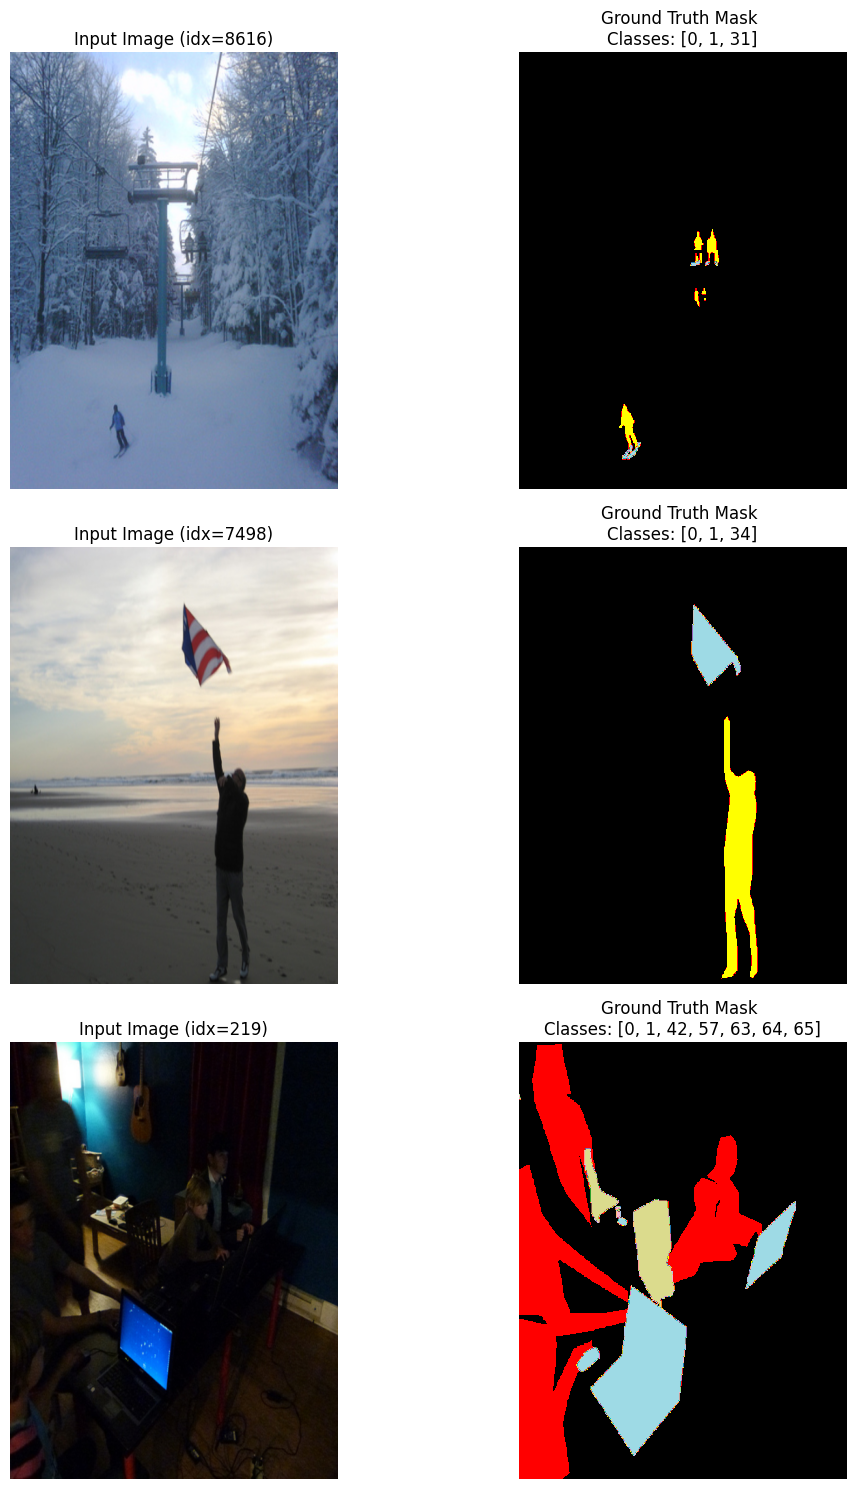


✅ Image shape: torch.Size([3, 640, 480])
✅ Mask shape: torch.Size([640, 480])
✅ Mask dtype: torch.int64


In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#facciamo un check per verificare se la coppia immagine ground truth venga presa correttamente
# Funzione per denormalizzare l'immagine
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# CREAZIONE DELLA PALETTE DI COLORI ROBUSTA (NUOVO CODICE)
def create_robust_colormap(num_classes):
    # Genera una colormap con colori categorici (es. da 'tab20')
    base_cmap = plt.cm.get_cmap('tab20', num_classes)
    
    # Prendi i colori RGB normalizzati (0-1)
    colors = base_cmap(np.arange(num_classes))
    
    # -----------------------------------------------
    # FORZA COLORI AD ALTO CONTRASTO PER GLI INDICI BASSI
    # -----------------------------------------------
    
    # Indice 0 (Background): Forzato a Nero (massimo contrasto con l'immagine originale)
    colors[0] = [0.0, 0.0, 0.0, 1.0] 
    
    # Indice 1 (Person/Oggetto Importante): Forzato a Rosso Vivace
    if num_classes > 1:
        colors[1] = [1.0, 0.0, 0.0, 1.0] # Rosso
        
    # Indice 2 (Se presente): Forzato a Giallo (per debug)
    if num_classes > 2:
        colors[2] = [1.0, 1.0, 0.0, 1.0] # Giallo
    
    # Crea la nuova colormap
    custom_cmap = ListedColormap(colors)
    return custom_cmap

# Determina NUM_CLASSES come hai fatto nel tuo codice di mapping
# Supponendo che sia 81
NUM_CLASSES = 81 
custom_cmap = create_robust_colormap(NUM_CLASSES)

# Visualizza 3 esempi random
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for i in range(3):
    # Prendi esempio random
    idx = np.random.randint(0, len(train_dataset))
    img, mask = train_dataset[idx]
    
    # Denormalizza immagine per visualizzazione
    img_show = denormalize(img).permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0, 1)  # Clamp tra 0 e 1
    
    # Visualizza
    axes[i, 0].imshow(img_show)
    axes[i, 0].set_title(f'Input Image (idx={idx})')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask.numpy(), cmap=custom_cmap)
    axes[i, 1].set_title(f'Ground Truth Mask \nClasses: {torch.unique(mask).tolist()}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Check dimensioni
print(f"\n✅ Image shape: {img.shape}")
print(f"✅ Mask shape: {mask.shape}")
print(f"✅ Mask dtype: {mask.dtype}")

In [26]:
import torchvision.models.segmentation as seg
import torch.nn as nn
import torch

#script per inizializzare i pesi della rete fcn_resnet50 con Xavier
model = seg.fcn_resnet50(weights=None)   # senza pretraining

print(model.classifier)  # contiene model.classifier[4] = Conv2d(..., num_classes_orig)

# Sostituisci solo l'ultimo conv layer
model.classifier[4] = nn.Conv2d(in_channels=512, out_channels=NUM_CLASSES, kernel_size=1)

print(model.classifier) 

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


FCNHead(
  (0): Conv2d(2048, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Conv2d(512, 21, kernel_size=(1, 1), stride=(1, 1))
)
FCNHead(
  (0): Conv2d(2048, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Conv2d(512, 81, kernel_size=(1, 1), stride=(1, 1))
)


In [27]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean', ignore_index=255):
        """
        Focal Loss per segmentazione semantica
        
        Args:
            alpha: Pesi per classe (Tensor) o None
            gamma: Focusing parameter (default=2)
            reduction: 'mean', 'sum', 'none'
            ignore_index: Classe da ignorare (es. padding)
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index
    
    def forward(self, inputs, targets):
        """
        Args:
            inputs: (B, C, H, W) - logits
            targets: (B, H, W) - class indices
        """
        # Cross Entropy Loss base
        ce_loss = F.cross_entropy(
            inputs, 
            targets, 
            weight=self.alpha,  # ← Applica class weights
            reduction='none',
            ignore_index=self.ignore_index
        )
        
        # Focal Term
        pt = torch.exp(-ce_loss)  # Probabilità classe corretta
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print ('FATTO')

#criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)

FATTO


Analizziamo adesso a monte se l'architettura di rete funziona, dopo passiamo al babysitting all'interno del ciclo di train.

In [29]:
#sanity check per quanto riguarda la Cross Entropy Loss
model.to(device)
lr = 1e-3

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0) #imposta L2 = ||w||^2
criterion = nn.CrossEntropyLoss()

# --- Batch fittizio ---
torch.manual_seed(42)
optimizer.zero_grad()
fake_images = torch.randn(1, 3, 640, 480, device = device)     # batch di n immagini
fake_masks  = torch.randint(0, 81, (1, 640, 480), device = device) # n etichette casuali

# --- Forward pass ---
outputs = model(fake_images)['out']   # [B, NUM_CLASSES, H, W]

# --- Loss iniziale ---
# valore teorico iniziale atteso = -log(1/NUM_CLASSES)
loss = criterion(outputs, fake_masks)
print("Loss iniziale =", loss.item())
print("Valore teorico atteso =", torch.log(torch.tensor(NUM_CLASSES, dtype=torch.float)).item())

Loss iniziale = 4.453855991363525
Valore teorico atteso = 4.394449234008789


La focal è una loss che usa due iperparametri α e γ, che nel nostro caso valgono rispettivamente 1 e 2. Il valore atteso è dato da (1-1/NUM_CLASSES)^/(γ)*ln(NUM_CLASSES).

In [36]:
#analisi del sanity check per quanto riguarda Focal loss
outputs = model(fake_images)['out']   # [B, NUM_CLASSES, H, W]

criterion_2 = FocalLoss(alpha=None, gamma=2)
loss = criterion_2(outputs, fake_masks)

print("Loss iniziale =", loss.item())
print("Valore teorico atteso =", ((1 - 1/NUM_CLASSES)**(2))*torch.log(torch.tensor(NUM_CLASSES, dtype=torch.float)).item())

Loss iniziale = 4.347963809967041
Valore teorico atteso = 4.286614098103375


In [30]:
#sanity check per quanto riguarda dice loss
outputs = model(fake_images)['out']   # [B, NUM_CLASSES, H, W]

criterion_2 = DiceLoss(mode='multiclass')
loss = criterion_2(outputs, fake_masks)

print("Loss iniziale =", loss.item())
print("Valore teorico atteso =", )

Loss iniziale = 0.9877911806106567
Valore teorico atteso = 0.9876543209876543


In [32]:
#analisi del sanity check per quanto riguarda Jaccard loss
outputs = model(fake_images)['out']   # [B, NUM_CLASSES, H, W]

criterion_2 = JaccardLoss(mode='multiclass')
loss = criterion_2(outputs, fake_masks)

print("Loss iniziale =", loss.item())
print("Valore teorico atteso =", 1 - 1/NUM_CLASSES)

Loss iniziale = 0.9938562512397766
Valore teorico atteso = 0.9876543209876543


In [37]:
import gc
del fake_images, fake_masks, outputs
torch.cuda.empty_cache()
gc.collect()

41381

In [43]:
import torch
from tqdm import tqdm
import numpy as np

# Definisci il dispositivo (es. 'cuda:0')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parametri
background_index = 0 # L'indice che vuoi contare come background (o ignore index)

# Inizializza il contatore su CPU (dove verrà accumulato il risultato finale)
# all_class_counts ora conterrà i conteggi per TUTTE le classi (0 a NUM_CLASSES-1)
all_class_counts = torch.zeros(NUM_CLASSES, dtype=torch.long) 


print(f"Inizio conteggio pixel sul dispositivo: {device}")
print(f"Conteggio della classe {background_index} (Background) INCLUSO.")

# ----------------- Loop di Conteggio -----------------
# **Importante:** Se il tuo train_loader usa un sampler che produce batch di dimensioni diverse
# (es. se l'ultimo batch è più piccolo), non influisce sulla correttezza del conteggio totale.

for _, gt in tqdm(train_loader, desc="Counting All Pixels"):
    
    # Sposta la Ground Truth sulla GPU
    gt = gt.to(device)
    
    # Vettorizzazione
    gt = gt.view(-1)
    
    # Calcolo del conteggio dei pixel per TUTTE le classi (incluso l'indice 0)
    # L'operazione bincount avviene sulla GPU.
    counts = torch.bincount(gt, minlength=NUM_CLASSES)
    
    # Sposta il risultato sulla CPU e accumula
    all_class_counts += counts.cpu()
    
# ----------------- Stampa Risultati -----------------

# Estrai il conteggio totale e del background
total_pixels = all_class_counts.sum().item()
background_pixels = all_class_counts[background_index].item()
object_pixels = total_pixels - background_pixels

background_percentage = (background_pixels / total_pixels) * 100
object_percentage = (object_pixels / total_pixels) * 100

print("\n---------------------------------------------------")
print("             ANALISI COMPLETA DELLA DISTRIBUZIONE PIXEL")
print("---------------------------------------------------")
print(f"Totale Assoluto dei Pixel Contati: {total_pixels:,}")
print("-" * 50)
print(f"PIXEL BACKGROUND (Classe {background_index}): {background_pixels:,} pixel ({background_percentage:.4f}%)")
print(f"PIXEL OGGETTO (Classi 1 a {NUM_CLASSES - 1}): {object_pixels:,} pixel ({object_percentage:.4f}%)")
print("-" * 50)

# Stampa la distribuzione dettagliata delle classi oggetto
print("\nDISTRIBUZIONE DETTAGLIATA CLASSI OGGETTO (Percentuale sul totale PIXEL OGGETTO):")

# Ricalcola le percentuali solo sugli oggetti per l'analisi dettagliata (come fatto prima)
for i in range(1, NUM_CLASSES):
    count = all_class_counts[i].item()
    if object_pixels > 0:
        class_percentages_on_objects = (count / object_pixels) * 100
    else:
        class_percentages_on_objects = 0
        
    print(f"Classe {i}: {class_percentages_on_objects:.4f}% ({count:,} pixels)")

print("-" * 50)

Inizio conteggio pixel sul dispositivo: cuda
Conteggio della classe 0 (Background) INCLUSO.


Counting All Pixels: 100%|██████████| 1596/1596 [02:13<00:00, 11.99it/s]


---------------------------------------------------
             ANALISI COMPLETA DELLA DISTRIBUZIONE PIXEL
---------------------------------------------------
Totale Assoluto dei Pixel Contati: 2,940,211,200
--------------------------------------------------
PIXEL BACKGROUND (Classe 0): 1,947,786,332 pixel (66.2465%)
PIXEL OGGETTO (Classi 1 a 80): 992,424,868 pixel (33.7535%)
--------------------------------------------------

DISTRIBUZIONE DETTAGLIATA CLASSI OGGETTO (Percentuale sul totale PIXEL OGGETTO):
Classe 1: 23.5557% (233,773,085 pixels)
Classe 2: 0.4845% (4,808,507 pixels)
Classe 3: 2.1726% (21,560,989 pixels)
Classe 4: 1.4751% (14,638,949 pixels)
Classe 5: 0.6006% (5,960,980 pixels)
Classe 6: 2.7872% (27,661,066 pixels)
Classe 7: 1.7736% (17,601,663 pixels)
Classe 8: 2.4712% (24,524,700 pixels)
Classe 9: 0.6696% (6,645,560 pixels)
Classe 10: 0.1368% (1,357,568 pixels)
Classe 11: 0.2639% (2,619,470 pixels)
Classe 12: 0.4279% (4,246,145 pixels)
Classe 13: 0.1340% (1,329,608 p

Il risultato ottenuto è soddisfacente: gli oggetti sono al di sopra del 30%, per cui il background non condizionerà in maniera eccessiva l'andamento del nostro training, rovinando l'ottimizzazione dei pesi.

Adesso possiamo procedere con lo studio degli iper-parametri ottimali per iniziare il train. In questa sezione lo facciamo per Jaccard e per Dice Loss

In [50]:
import numpy as np
import gc


# DATASET RIDOTTO PER RICERCA VELOCE IPERPARAMETRI
print("🔧 Creating REDUCED dataset for fast hyperparameter search...\n")

# SPLIT RIDOTTO: 100 train + 20 val (invece di 9500 + 2000)
train_ids_reduced = train_ids[:100]
val_ids_reduced = val_ids[:20]

print(f"✅ Reduced split:")
print(f"  Train: {len(train_ids_reduced)} images (was {len(train_ids)})")
print(f"  Val: {len(val_ids_reduced)} images (was {len(val_ids)})\n")

# CREA DATASET RIDOTTI
train_dataset_search = COCOSegmentationDataset(
    img_dir=TRAIN_IMG_DIR,
    ann_file=TRAIN_ANN_FILE,
    img_ids=train_ids_reduced,
    class_mapping=coco_id_to_index,
    augment=False  # ← No augment per velocità
)

val_dataset_search = COCOSegmentationDataset(
    img_dir=VAL_IMG_DIR,
    ann_file=VAL_ANN_FILE,
    img_ids=val_ids_reduced,
    class_mapping=coco_id_to_index,
    augment=False
)

# DATALOADER CON BATCH SIZE MAGGIORE (più pixel = più batch size)
train_loader_search = DataLoader(
    train_dataset_search,
    batch_size=6,  # ← Era 8, ora 16 (immagini più piccole)
    shuffle=True,
    pin_memory=True,
    num_workers=4
)

val_loader_search = DataLoader(
    val_dataset_search,
    batch_size=6,
    shuffle=False,
    pin_memory=True,
    num_workers=4
)

print(f"✅ Search DataLoaders ready:")
print(f"  Train batches: {len(train_loader_search)}")
print(f"  Val batches: {len(val_loader_search)}\n")

🔧 Creating REDUCED dataset for fast hyperparameter search...

✅ Reduced split:
  Train: 100 images (was 9571)
  Val: 20 images (was 1353)

loading annotations into memory...
Done (t=1.11s)
creating index...
index created!
Dataset: 100 images | Size: (640, 480) | Aug: False
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
Dataset: 20 images | Size: (640, 480) | Aug: False
✅ Search DataLoaders ready:
  Train batches: 17
  Val batches: 4



In [51]:
#Ricerchiamo gli iperparametri migliori, in questo caso per la dice loss
num_experiments = 30
epochs_search = 10      

np.random.seed(42)
lr_samples = 10**np.random.uniform(-4, -3, num_experiments)
reg_samples = 10**np.random.uniform(-4, -3, num_experiments)

results = []

print(f"{'='*60}")
print(f"🚀 FAST HYPERPARAMETER SEARCH")
print(f"{'='*60}")
print(f"Experiments: {num_experiments}")
print(f"Epochs per exp: {epochs_search}")
print(f"Dataset: 100 train + 20 val")
print(f"Image size: 640x480")
print(f"Estimated time: ~1-2 hours")
print(f"{'='*60}\n")

for i in range(num_experiments):
    lr = lr_samples[i]
    reg = reg_samples[i]
    
    print(f"Exp {i+1}/{num_experiments} | LR: {lr:.2e} | Reg: {reg:.2e}")
    
    # Crea modello
    model_temp = seg.fcn_resnet50(weights=None)
    model_temp.classifier[4] = nn.Conv2d(512, NUM_CLASSES, kernel_size=1)
    model_temp = model_temp.to(device)
    
    optimizer = optim.Adam(model_temp.parameters(), lr=lr, weight_decay=reg)
    criterion = DiceLoss(mode='multiclass')
    
    # Training veloce
    for epoch in range(1, epochs_search + 1):
        model_temp.train()
        for imgs, masks in train_loader_search:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model_temp(imgs)['out']
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
    
    # Validation
    model_temp.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, masks in val_loader_search:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model_temp(imgs)['out']
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == masks).sum().item()
            total += masks.numel()
    
    val_loss /= len(val_loader_search)
    val_acc = correct / total
    
    results.append({'dice-lr': lr, 'dice-reg': reg, 'dice-val_loss': val_loss, 'dice-val_acc': val_acc})
    print(f"  → Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")
    
    # Libera memoria
    del model_temp, optimizer
    torch.cuda.empty_cache()
    gc.collect()

# Risultati
results_sorted = sorted(results, key=lambda x: x['dice-val_acc'], reverse=True)

print(f"\n{'='*60}")
print("📊 TOP 10 RESULTS")
print(f"{'='*60}\n")

for i, res in enumerate(results_sorted[:10], 1):
    print(f"{i:2d}. LR={res['dice-lr']:.2e} | Reg={res['dice-reg']:.2e} | "
          f"Loss={res['dice-val_loss']:.4f} | Acc={res['dice-val_acc']:.4f}")

best = results_sorted[0]
best_dice = best
print(f"\n🏆 BEST HYPERPARAMETERS:")
print(f"  LR: {best['dice-lr']:.6e}")
print(f"  Weight Decay: {best['dice-reg']:.6e}")
print(f"  Val Acc: {best['dice-val_acc']:.4f}")

BEST_LR = best['dice-lr']
BEST_REG = best['dice-reg']

print(f"\n✅ Use these for FULL training with 640x480 images!")

🚀 FAST HYPERPARAMETER SEARCH
Experiments: 30
Epochs per exp: 10
Dataset: 100 train + 20 val
Image size: 640x480
Estimated time: ~1-2 hours

Exp 1/30 | LR: 2.37e-04 | Reg: 4.05e-04
  → Val Loss: 0.1219 | Val Acc: 0.5094

Exp 2/30 | LR: 8.93e-04 | Reg: 1.48e-04
  → Val Loss: 0.1314 | Val Acc: 0.7431

Exp 3/30 | LR: 5.40e-04 | Reg: 1.16e-04
  → Val Loss: 0.1307 | Val Acc: 0.6130

Exp 4/30 | LR: 3.97e-04 | Reg: 8.89e-04
  → Val Loss: 0.1293 | Val Acc: 0.7190

Exp 5/30 | LR: 1.43e-04 | Reg: 9.24e-04
  → Val Loss: 0.1136 | Val Acc: 0.7275

Exp 6/30 | LR: 1.43e-04 | Reg: 6.43e-04
  → Val Loss: 0.1153 | Val Acc: 0.7262

Exp 7/30 | LR: 1.14e-04 | Reg: 2.02e-04
  → Val Loss: 0.1108 | Val Acc: 0.7458

Exp 8/30 | LR: 7.35e-04 | Reg: 1.25e-04
  → Val Loss: 0.1325 | Val Acc: 0.5447

Exp 9/30 | LR: 3.99e-04 | Reg: 4.83e-04
  → Val Loss: 0.1247 | Val Acc: 0.7269

Exp 10/30 | LR: 5.11e-04 | Reg: 2.76e-04
  → Val Loss: 0.1312 | Val Acc: 0.6902

Exp 11/30 | LR: 1.05e-04 | Reg: 1.32e-04
  → Val Loss: 0.11

In [53]:
#Ricerchiamo lo stesso fatto prima, solo che in questo caso usando la Jaccard Loss
num_experiments = 30
epochs_search = 10      

np.random.seed(42)
lr_samples = 10**np.random.uniform(-4, -3, num_experiments)
reg_samples = 10**np.random.uniform(-4, -3, num_experiments)

print(f"{'='*60}")
print(f"🚀 FAST HYPERPARAMETER SEARCH")
print(f"{'='*60}")
print(f"Experiments: {num_experiments}")
print(f"Epochs per exp: {epochs_search}")
print(f"Dataset: 100 train + 20 val")
print(f"Image size: 640x480")
print(f"Estimated time: ~1-2 hours")
print(f"{'='*60}\n")

for i in range(num_experiments):
    lr = lr_samples[i]
    reg = reg_samples[i]
    
    print(f"Exp {i+1}/{num_experiments} | LR: {lr:.2e} | Reg: {reg:.2e}")
    
    # Crea modello
    model_temp = seg.fcn_resnet50(weights=None)
    model_temp.classifier[4] = nn.Conv2d(512, NUM_CLASSES, kernel_size=1)
    model_temp = model_temp.to(device)
    
    optimizer = optim.Adam(model_temp.parameters(), lr=lr, weight_decay=reg)
    criterion = DiceLoss(mode='multiclass')
    
    # Training veloce
    for epoch in range(1, epochs_search + 1):
        model_temp.train()
        for imgs, masks in train_loader_search:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model_temp(imgs)['out']
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
    
    # Validation
    model_temp.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, masks in val_loader_search:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model_temp(imgs)['out']
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == masks).sum().item()
            total += masks.numel()
    
    val_loss /= len(val_loader_search)
    val_acc = correct / total
    
    results.append({'jaccard-lr': lr, 'jaccard-reg': reg, 'jaccard-val_loss': val_loss, 'jaccard-val_acc': val_acc})
    print(f"  → Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")
    
    # Libera memoria
    del model_temp, optimizer
    torch.cuda.empty_cache()
    gc.collect()

# Risultati
jaccard_results = [r for r in results if 'jaccard-val_acc' in r]

results_sorted = sorted(
    jaccard_results,
    key=lambda x: x['jaccard-val_acc'],
    reverse=True
)

print(f"\n{'='*60}")
print("📊 TOP 10 RESULTS")
print(f"{'='*60}\n")

for i, res in enumerate(results_sorted[:10], 1):
    print(f"{i:2d}. LR={res['jaccard-lr']:.2e} | Reg={res['jaccard-reg']:.2e} | "
          f"Loss={res['jaccard-val_loss']:.4f} | Acc={res['jaccard-val_acc']:.4f}")

best = results_sorted[0]
best_jaccard = best
print(f"\n🏆 BEST HYPERPARAMETERS:")
print(f"  LR: {best['jaccard-lr']:.6e}")
print(f"  Weight Decay: {best['jaccard-reg']:.6e}")
print(f"  Val Acc: {best['jaccard-val_acc']:.4f}")

BEST_LR = best['jaccard-lr']
BEST_REG = best['jaccard-reg']

print(f"\n✅ Use these for FULL training with 640x480 images!")

🚀 FAST HYPERPARAMETER SEARCH
Experiments: 30
Epochs per exp: 10
Dataset: 100 train + 20 val
Image size: 640x480
Estimated time: ~1-2 hours

Exp 1/30 | LR: 2.37e-04 | Reg: 4.05e-04
  → Val Loss: 0.1218 | Val Acc: 0.6954

Exp 2/30 | LR: 8.93e-04 | Reg: 1.48e-04
  → Val Loss: 0.1303 | Val Acc: 0.7535

Exp 3/30 | LR: 5.40e-04 | Reg: 1.16e-04
  → Val Loss: 0.1309 | Val Acc: 0.4697

Exp 4/30 | LR: 3.97e-04 | Reg: 8.89e-04
  → Val Loss: 0.1296 | Val Acc: 0.7351

Exp 5/30 | LR: 1.43e-04 | Reg: 9.24e-04
  → Val Loss: 0.1213 | Val Acc: 0.5872

Exp 6/30 | LR: 1.43e-04 | Reg: 6.43e-04
  → Val Loss: 0.1155 | Val Acc: 0.7672

Exp 7/30 | LR: 1.14e-04 | Reg: 2.02e-04
  → Val Loss: 0.1085 | Val Acc: 0.7295

Exp 8/30 | LR: 7.35e-04 | Reg: 1.25e-04
  → Val Loss: 0.1279 | Val Acc: 0.7288

Exp 9/30 | LR: 3.99e-04 | Reg: 4.83e-04
  → Val Loss: 0.1282 | Val Acc: 0.6709

Exp 10/30 | LR: 5.11e-04 | Reg: 2.76e-04
  → Val Loss: 0.1309 | Val Acc: 0.7527

Exp 11/30 | LR: 1.05e-04 | Reg: 1.32e-04
  → Val Loss: 0.10

In [54]:
with open("best_hyperparameters.txt", "w") as f:
    f.write("===== BEST HYPERPARAMETERS =====\n\n")

    f.write("JACCARD\n")
    f.write(f"LR: {best_jaccard['jaccard-lr']}\n")
    f.write(f"Weight Decay: {best_jaccard['jaccard-reg']}\n\n")

    f.write("DICE\n")
    f.write(f"LR: {best_dice['dice-lr']}\n")
    f.write(f"Weight Decay: {best_dice['dice-reg']}\n")

print("✅ Salvati SOLO i migliori LR e REG per Dice e Jaccard!")

✅ Salvati SOLO i migliori LR e REG per Dice e Jaccard!


In [58]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import time
import os

class SegmentationMetrics:
    def __init__(self, num_classes, ignore_index=None):
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def update(self, preds, targets):
        """Restituisce confusion matrix parziale di batch"""
        preds = preds.view(-1)
        targets = targets.view(-1)
        mask = (targets >= 0)
        if self.ignore_index is not None:
            mask &= (targets != self.ignore_index)

        hist = torch.bincount(
            self.num_classes * targets[mask] + preds[mask],
            minlength=self.num_classes ** 2
        ).reshape(self.num_classes, self.num_classes)

        return hist

    def compute_metrics(self, confmat):
        """Da confusion matrix calcola precision, recall, F1, IoU"""
        TP = torch.diag(confmat)
        FP = confmat.sum(0) - TP
        FN = confmat.sum(1) - TP
        TN = confmat.sum() - (TP + FP + FN)

        precision = TP / (TP + FP + 1e-6)
        recall = TP / (TP + FN + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)
        iou = TP / (TP + FP + FN + 1e-6)

        return precision, recall, f1, iou

Analisi dell'overfitting check con trainer loader di 1 immagine

In [60]:
from torch.utils.data import DataLoader, Subset

# Prendiamo SOLO la prima immagine reale del dataset
overfit_subset = Subset(train_dataset, [0])

overfit_loader = DataLoader(
    overfit_subset,
    batch_size=1,        # IMPORTANTISSIMO: 1 sola immagine
    shuffle=True,
    pin_memory=True if torch.cuda.is_available() else False,
    num_workers=4        # Evita bug nei notebook
)

img, mask = train_dataset[0]
index_list = []

print("IMG SHAPE:", img.shape)
print("MASK SHAPE:", mask.shape)
print("MASK DTYPE:", mask.dtype)
print("UNIQUE MASK VALUES:", torch.unique(mask))

#creo una lista di classi note nel mio train per valutare la media delle mie metriche
#solo sulle classi effettivamente presenti, e vedere se si overfittano anche loro
for tensor_value in torch.unique(mask):
    index_list.append(tensor_value.item())

print(index_list)


IMG SHAPE: torch.Size([3, 640, 480])
MASK SHAPE: torch.Size([640, 480])
MASK DTYPE: torch.int64
UNIQUE MASK VALUES: tensor([ 0,  3, 10])
[0, 3, 10]


In [61]:
class FCNTrainer:
    def __init__(self, model, train_loader, val_loader, device, 
                 lr=1e-4, weight_decay=1e-3, num_epochs=50, 
                 save_dir='checkpoints', loss_type='CrossEntropyLoss'):
        """
        Args:
            model: FCN-ResNet50 model
            train_loader: DataLoader per training
            val_loader: DataLoader per validation
            device: cuda o cpu
            lr: learning rate base
            weight_decay: regularization
            num_epochs: numero epoche
            save_dir: directory per salvare checkpoints
        """
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_epochs = num_epochs
        self.save_dir = save_dir
        self.loss_type = loss_type
        
        # Crea directory checkpoints
        os.makedirs(save_dir, exist_ok=True)
        
        # Optimizer
        self.optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=lr, 
            weight_decay=weight_decay,
            betas=(0.9, 0.999)
        )
        
        # OneCycleLR Scheduler
        self.scheduler = None
        
        # Loss e metric dal tutorial
        if (loss_type == 'CrossEntropyLoss'):
            self.criterion = nn.CrossEntropyLoss()
        if (loss_type == 'DiceLoss'):
            self.criterion = DiceLoss(mode='multiclass')
        if (loss_type == 'JaccardLoss'):
            self.criterion = JaccardLoss(mode='multiclass')
        self.metric = SegmentationMetrics(num_classes=NUM_CLASSES)
        
        # Storia metriche
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_miou': [],
            'val_miou': [],
            'train_f1': [],
            'val_f1': [],
            'train_precision': [],
            'val_precision': [],
            'train_recall': [],
            'val_recall': [],
            'lr': []
        }
        
        # Best model tracking
        self.min_loss = np.inf
        
        print(f"{'='*70}")
        print("✅ Trainer initialized:")
        print(f"  Base LR: {lr:.6e}")
        print(f"  Max LR: {lr * 5:.6e}")
        print(f"  Weight Decay: {weight_decay:.6e}")
        print(f"  Epochs: {num_epochs}")
        print(f"  Scheduler: OneCycleLR")
        print(f"  Device: {device}")
        print(f"  Checkpoint dir: {save_dir}")
        print(f"{'='*70}\n")
    
    def train_one_epoch(self, epoch, index_list):
        """Training per una singola epoca"""
        self.model.train()
        running_loss = 0.0
        
        
        pbar = tqdm(self.train_loader, 
                   desc=f"Epoch {epoch}/{self.num_epochs} [TRAIN]",
                   ncols=100)

        confmat_total = torch.zeros(self.metric.num_classes, self.metric.num_classes).to(self.device)
        
        for net_input, gt in pbar:
            net_input = net_input.to(self.device)
            gt = gt.to(self.device)
            
            # Training phase
            self.optimizer.zero_grad()
            out = self.model(net_input)['out']
            loss = self.criterion(out, gt)
            
            loss.backward()
            self.optimizer.step()
            if self.scheduler is not None:
                self.scheduler.step()  # Step scheduler ogni batch
            
            running_loss += loss.item()

            # Predizioni
            pred = torch.argmax(out, dim=1)

            # Aggiorna confusion matrix
            confmat_total += self.metric.update(pred, gt)

            # Fine epoca
            precision, recall, f1, iou = self.metric.compute_metrics(confmat_total)
            
            indices_tensor = torch.tensor(index_list, dtype=torch.long)
                
            #    Queste variabili (iou_selected, f1_selected, etc.) sono ora vettori
            #    contenenti solo i valori delle classi presenti (dimensione 7 nel tuo esempio).
            iou_selected = iou[indices_tensor]
            f1_selected = f1[indices_tensor]
            precision_selected = precision[indices_tensor]
            recall_selected = recall[indices_tensor]
            
            mean_iou = iou_selected.mean().item()
            mean_f1 = f1_selected.mean().item()
            mean_precision = precision_selected.mean().item()
            mean_recall = recall_selected.mean().item()
            
            # Update progress bar
            current_lr = self.optimizer.param_groups[0]['lr']
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{current_lr:.2e}'
            })

        
        # Media su tutti i batch
        running_loss = running_loss / len(self.train_loader)
        
        return running_loss, mean_iou, mean_precision, mean_recall, mean_f1
    
    def validate(self, epoch, index_list):
        """Validation"""
        self.model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            pbar = tqdm(self.val_loader, 
                       desc=f"Epoch {epoch}/{self.num_epochs} [VAL]  ",
                       ncols=100)
            
            confmat_total = torch.zeros(self.metric.num_classes, self.metric.num_classes).to(self.device)

            for net_input, gt in pbar:
                net_input = net_input.to(self.device)
                gt = gt.to(self.device)
                
                # Validation phase
                out = self.model(net_input)['out']
                val_loss = self.criterion(out, gt)
                
                running_val_loss += val_loss.item()

                # Predizioni
                pred = torch.argmax(out, dim=1)
        
                # Aggiorna confusion matrix
                confmat_total += self.metric.update(pred, gt)
        
                # Fine epoca
                precision, recall, f1, iou = self.metric.compute_metrics(confmat_total)
                
                indices_tensor = torch.tensor(index_list, dtype=torch.long)
                
                #    Queste variabili (iou_selected, f1_selected, etc.) sono ora vettori
                #    contenenti solo i valori delle classi presenti (dimensione 7 nel tuo esempio).
                iou_selected = iou[indices_tensor]
                f1_selected = f1[indices_tensor]
                precision_selected = precision[indices_tensor]
                recall_selected = recall[indices_tensor]
                
                mean_iou = iou_selected.mean().item()
                mean_f1 = f1_selected.mean().item()
                mean_precision = precision_selected.mean().item()
                mean_recall = recall_selected.mean().item()

                pbar.set_postfix({
                    'loss': f'{val_loss.item():.4f}',
                })
        
        # Media
        running_val_loss = running_val_loss / len(self.val_loader)
        
        return running_val_loss, mean_iou, mean_precision, mean_recall, mean_f1
    
    def save_checkpoint(self, epoch, filename):
        """Salva checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            #'scheduler_state_dict': self.scheduler.state_dict(),
            'history': self.history,
            'min_loss': self.min_loss
        }
        filepath = os.path.join(self.save_dir, filename)
        torch.save(checkpoint, filepath)
        print(f"    💾 Saved checkpoint: {filename}")

    def load_last_checkpoint(self, folder):
        """
        Cerca automaticamente il checkpoint più recente nella cartella.
        Se nessun file .pth esiste → torna epoch 1.
        """
        if not os.path.isdir(folder):
            print(f"⚠️ La cartella {folder} non esiste.")
            return 1
    
        files = [f for f in os.listdir(folder) if f.endswith(".pth")]
        if len(files) == 0:
            print(f"⚠️ Nessun checkpoint .pth trovato in {folder}.")
            return 1
    
        # ordina per numero di epoca
        files.sort(key=lambda x: os.path.getmtime(os.path.join(folder, x)))
    
        last_file = files[-1]
        full_path = os.path.join(folder, last_file)
    
        print(f"📂 Caricamento dell’ultimo checkpoint trovato: {last_file}")
        return self.load_checkpoint(full_path)
    
    def load_checkpoint(self, filepath):
        checkpoint = torch.load(filepath, map_location=self.device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        #self.scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        self.history = checkpoint["history"]
        self.min_loss = checkpoint["min_loss"]
    
        start_epoch = checkpoint["epoch"] + 1
        print(f"✅ Loaded checkpoint from epoch {checkpoint['epoch']}\n")
        return start_epoch
    
    def train(self, start_epoch=1, index_list = index_list):
        """Loop di training completo"""
        print(f"{'='*70}")
        print("🚀 STARTING TRAINING")
        print(f"{'='*70}\n")
        
        fit_time = time.time()
        
        for epoch in range(start_epoch, self.num_epochs + 1):
            since = time.time()
            
            # Train
            train_loss, train_iou, train_precision, train_recall, train_f1 = self.train_one_epoch(epoch, index_list)
            
            # Validation
            val_loss, val_iou, val_precision, val_recall, val_f1 = self.validate(epoch, index_list)
            
            # Salva metriche
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_miou'].append(train_iou)
            self.history['val_miou'].append(val_iou)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(val_f1)
            self.history['train_precision'].append(train_precision)
            self.history['val_precision'].append(val_precision)
            self.history['train_recall'].append(train_recall)
            self.history['val_recall'].append(val_recall)
            self.history['lr'].append(self.optimizer.param_groups[0]['lr'])
            
            # Print summary 
            epoch_time = (time.time() - since) / 60
            print(f"\n{'='*70}")
            print(f"Epoch: {epoch}/{self.num_epochs}  "
                  f"Train Loss: {train_loss:.5f}  "
                  f"Val Loss: {val_loss:.5f}  "
                  f"Train mIoU: {train_iou:.5f}  "
                  f"Val mIoU: {val_iou:.5f}  "
                  f"Train mPrecion: {train_precision:.5f}  "
                  f"Val mPrecision: {val_precision:.5f}  "
                  f"Train mRecall: {train_recall:.5f}  "
                  f"Val mRecall: {val_recall:.5f}  "
                  f"Train mF1: {train_f1:.5f}  "
                  f"Val mF1: {val_f1:.5f}  "
                  f"Time: {epoch_time:.2f}m")
            
            print(f"{'='*70}\n")
        
        print("\n✅ Training completed!")
        print(f"✅ Best model saved with Val Loss: {self.min_loss:.5f}")
    
    def plot_curves(self):
        """Visualizza curve di training: Loss, mIoU, F1, Precision e Recall"""
        epochs = range(1, len(self.history['train_loss']) + 1)
        
        fig, axes = plt.subplots(2, 2, figsize=(18, 10))
        
        # ------------------- Loss -------------------
        axes[0, 0].plot(epochs, self.history['train_loss'], 'b-', 
                        label='Train Loss', linewidth=2, marker='o', markersize=3)
        axes[0, 0].plot(epochs, self.history['val_loss'], 'r-', 
                        label='Val Loss', linewidth=2, marker='s', markersize=3)
        axes[0, 0].set_xlabel('Epoch', fontsize=12)
        axes[0, 0].set_ylabel('Loss', fontsize=12)
        axes[0, 0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
        axes[0, 0].legend(fontsize=11)
        axes[0, 0].grid(True, alpha=0.3)
        
        # ------------------- mIoU -------------------
        axes[0, 1].plot(epochs, self.history['train_miou'], 'b-', 
                        label='Train mIoU', linewidth=2, marker='o', markersize=3)
        axes[0, 1].plot(epochs, self.history['val_miou'], 'r-', 
                        label='Val mIoU', linewidth=2, marker='s', markersize=3)
        axes[0, 1].set_xlabel('Epoch', fontsize=12)
        axes[0, 1].set_ylabel('mIoU', fontsize=12)
        axes[0, 1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
        axes[0, 1].legend(fontsize=11)
        axes[0, 1].grid(True, alpha=0.3)
        
        # ------------------- F1 Score -------------------
        axes[1, 0].plot(epochs, self.history['train_f1'], 'b-', 
                        label='Train F1', linewidth=2, marker='o', markersize=3)
        axes[1, 0].plot(epochs, self.history['val_f1'], 'r-', 
                        label='Val F1', linewidth=2, marker='s', markersize=3)
        axes[1, 0].set_xlabel('Epoch', fontsize=12)
        axes[1, 0].set_ylabel('F1 Score', fontsize=12)
        axes[1, 0].set_title('Training vs Validation F1 Score', fontsize=14, fontweight='bold')
        axes[1, 0].legend(fontsize=11)
        axes[1, 0].grid(True, alpha=0.3)
        
        # ------------------- Precision & Recall -------------------
        axes[1, 1].plot(epochs, self.history['train_precision'], 'b-', 
                        label='Train Precision', linewidth=2, marker='o', markersize=3)
        axes[1, 1].plot(epochs, self.history['val_precision'], 'r-', 
                        label='Val Precision', linewidth=2, marker='s', markersize=3)
        axes[1, 1].plot(epochs, self.history['train_recall'], 'b--', 
                        label='Train Recall', linewidth=2, marker='o', markersize=3)
        axes[1, 1].plot(epochs, self.history['val_recall'], 'r--', 
                        label='Val Recall', linewidth=2, marker='s', markersize=3)
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].set_ylabel('Precision / Recall', fontsize=12)
        axes[1, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
        axes[1, 1].legend(fontsize=11)
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Salva plot
        plot_path = os.path.join(self.save_dir, f'training_curves_{self.criterion}.png')
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"✅ Training curves saved to {plot_path}")
        
        plt.show()
        
        # ------------------- Analisi finale -------------------
        print(f"\n{'='*70}")
        print("📊 TRAINING ANALYSIS:")
        print(f"{'='*70}\n")
        
        final_train_loss = self.history['train_loss'][-1]
        final_val_loss = self.history['val_loss'][-1]
        final_train_miou = self.history['train_miou'][-1]
        final_val_miou = self.history['val_miou'][-1]
        final_train_f1 = self.history['train_f1'][-1]
        final_val_f1 = self.history['val_f1'][-1]
        
        gap_loss = final_val_loss - final_train_loss
        gap_miou = final_train_miou - final_val_miou
        gap_f1 = final_train_f1 - final_val_f1
        
        print(f"  Final Train Loss: {final_train_loss:.5f}")
        print(f"  Final Val Loss:   {final_val_loss:.5f}")
        print(f"  Loss Gap:         {gap_loss:.5f}\n")
        
        print(f"  Final Train mIoU: {final_train_miou:.5f}")
        print(f"  Final Val mIoU:   {final_val_miou:.5f}")
        print(f"  mIoU Gap:         {gap_miou:.5f}\n")
        
        print(f"  Final Train F1:   {final_train_f1:.5f}")
        print(f"  Final Val F1:     {final_val_f1:.5f}")
        print(f"  F1 Gap:           {gap_f1:.5f}\n")
        
        print(f"  Best Val Loss:    {self.min_loss:.5f}")
        
        if gap_loss > 0.3:
            print(f"\n  ⚠️ OVERFITTING DETECTED! (Loss gap > 0.3)")
        elif gap_loss > 0.15:
            print(f"\n  ⚠️ Possible overfitting (Loss gap > 0.15)")
        else:
            print(f"\n  ✅ Good generalization!")
        
        print(f"{'='*70}\n")


✅ Trainer initialized:
  Base LR: 1.000000e-02
  Max LR: 5.000000e-02
  Weight Decay: 0.000000e+00
  Epochs: 300
  Scheduler: OneCycleLR
  Device: cuda
  Checkpoint dir: checkpoints

🚀 STARTING TRAINING



Epoch 1/300 [VAL]  : 100%|███████████████████████████████| 1/1 [00:00<00:00,  2.69it/s, loss=0.0350]



Epoch: 1/300  Train Loss: 0.03634  Val Loss: 0.03499  Train mIoU: 0.00094  Val mIoU: 0.03014  Train mPrecion: 0.33123  Val mPrecision: 0.03014  Train mRecall: 0.00096  Val mRecall: 0.33333  Train mF1: 0.00188  Val mF1: 0.05528  Time: 0.02m



Epoch 2/300 [VAL]  : 100%|███████████████████████████████| 1/1 [00:00<00:00,  2.68it/s, loss=0.0351]



Epoch: 2/300  Train Loss: 0.03119  Val Loss: 0.03508  Train mIoU: 0.26283  Val mIoU: 0.02864  Train mPrecion: 0.34913  Val mPrecision: 0.02890  Train mRecall: 0.41919  Val mRecall: 0.30206  Train mF1: 0.34572  Val mF1: 0.05275  Time: 0.01m



...


Epoch: 298/300  Train Loss: 0.00815  Val Loss: 0.00853  Train mIoU: 0.67897  Val mIoU: 0.65985  Train mPrecion: 0.87210  Val mPrecision: 0.77810  Train mRecall: 0.72530  Val mRecall: 0.76505  Train mF1: 0.77973  Val mF1: 0.77018  Time: 0.01m



Epoch 299/300 [VAL]  : 100%|█████████████████████████████| 1/1 [00:00<00:00,  2.97it/s, loss=0.0076]



Epoch: 299/300  Train Loss: 0.00676  Val Loss: 0.00758  Train mIoU: 0.72198  Val mIoU: 0.70113  Train mPrecion: 0.91962  Val mPrecision: 0.85831  Train mRecall: 0.75695  Val mRecall: 0.75587  Train mF1: 0.81724  Val mF1: 0.79840  Time: 0.01m



Epoch 300/300 [VAL]  : 100%|█████████████████████████████| 1/1 [00:00<00:00,  2.94it/s, loss=0.0075]



Epoch: 300/300  Train Loss: 0.00678  Val Loss: 0.00748  Train mIoU: 0.72207  Val mIoU: 0.69789  Train mPrecion: 0.92124  Val mPrecision: 0.85815  Train mRecall: 0.75628  Val mRecall: 0.75896  Train mF1: 0.81721  Val mF1: 0.79863  Time: 0.01m


✅ Training completed!
✅ Best model saved with Val Loss: inf
✅ Training curves saved to checkpoints/training_curves_DiceLoss().png


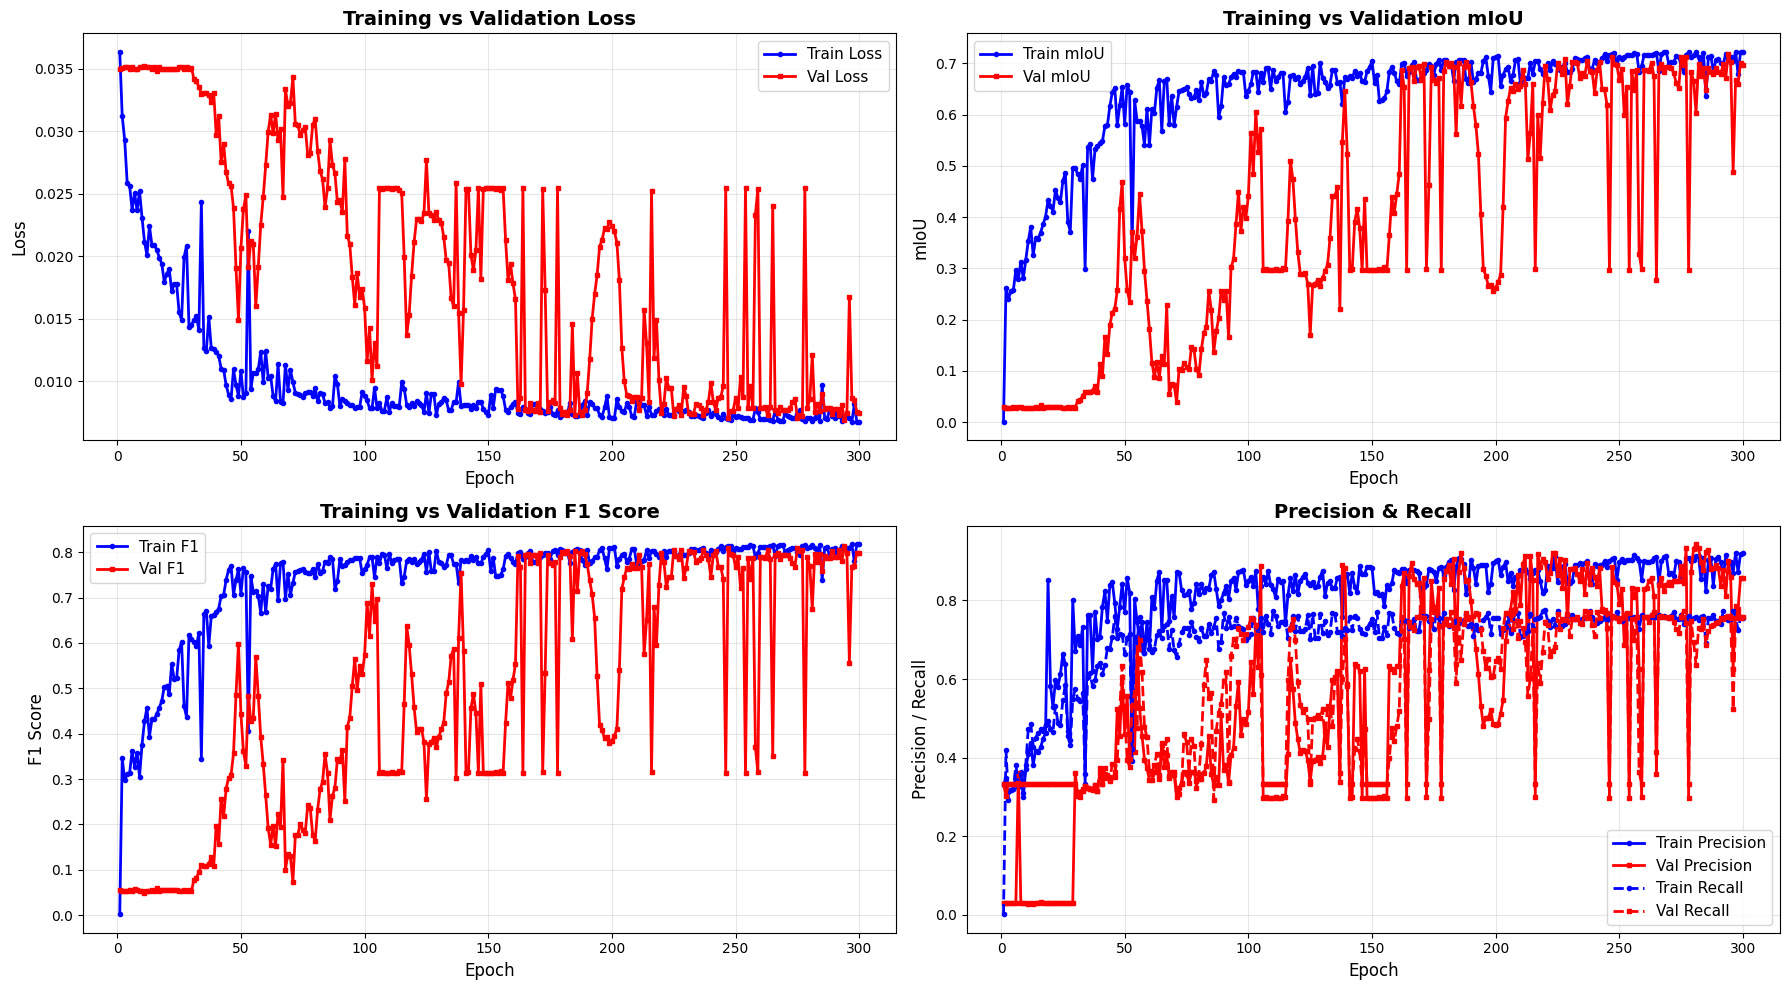


📊 TRAINING ANALYSIS:

  Final Train Loss: 0.00678
  Final Val Loss:   0.00748
  Loss Gap:         0.00070

  Final Train mIoU: 0.72207
  Final Val mIoU:   0.69789
  mIoU Gap:         0.02418

  Final Train F1:   0.81721
  Final Val F1:     0.79863
  F1 Gap:           0.01859

  Best Val Loss:    inf

  ✅ Good generalization!



In [63]:
BEST_LR = 10e-3
BEST_REG = 0

trainer = FCNTrainer(
    model=model,
    train_loader=overfit_loader,      # ← Usa il FULL 640x480!
    val_loader=overfit_loader,
    device=device,
    lr=BEST_LR,                     # ← Dal tuo hyperparameter search
    weight_decay=BEST_REG,          # ← Dal tuo hyperparameter search
    num_epochs=300,
    save_dir='checkpoints',          # ← Directory per salvataggio
    loss_type = 'DiceLoss'
)

# 3. TRAINING COMPLETO
#start_epoch = trainer.load_last_checkpoint('/kaggle/working/checkpoints')
trainer.train(index_list = index_list)

# 4. Plot curve
trainer.plot_curves()

✅ Trainer initialized:
  Base LR: 1.000000e-02
  Max LR: 5.000000e-02
  Weight Decay: 0.000000e+00
  Epochs: 300
  Scheduler: OneCycleLR
  Device: cuda
  Checkpoint dir: checkpoints

🚀 STARTING TRAINING



Epoch 1/300 [VAL]  : 100%|███████████████████████████████| 1/1 [00:00<00:00,  2.62it/s, loss=0.0176]



Epoch: 1/300  Train Loss: 0.01190  Val Loss: 0.01759  Train mIoU: 0.67972  Val mIoU: 0.52651  Train mPrecion: 0.90097  Val mPrecision: 0.69009  Train mRecall: 0.72123  Val mRecall: 0.67232  Train mF1: 0.78541  Val mF1: 0.65281  Time: 0.02m



Epoch 2/300 [VAL]  : 100%|███████████████████████████████| 1/1 [00:00<00:00,  2.64it/s, loss=0.0152]



Epoch: 2/300  Train Loss: 0.01660  Val Loss: 0.01518  Train mIoU: 0.55326  Val mIoU: 0.59116  Train mPrecion: 0.68985  Val mPrecision: 0.75405  Train mRecall: 0.70012  Val mRecall: 0.68807  Train mF1: 0.68117  Val mF1: 0.71771  Time: 0.02m



...


Epoch: 298/300  Train Loss: 0.00998  Val Loss: 0.01076  Train mIoU: 0.73098  Val mIoU: 0.70985  Train mPrecion: 0.91309  Val mPrecision: 0.85723  Train mRecall: 0.77188  Val mRecall: 0.77855  Train mF1: 0.82337  Val mF1: 0.80721  Time: 0.01m



Epoch 299/300 [VAL]  : 100%|█████████████████████████████| 1/1 [00:00<00:00,  2.80it/s, loss=0.0107]



Epoch: 299/300  Train Loss: 0.00983  Val Loss: 0.01069  Train mIoU: 0.73462  Val mIoU: 0.71129  Train mPrecion: 0.91134  Val mPrecision: 0.85597  Train mRecall: 0.77838  Val mRecall: 0.77366  Train mF1: 0.82560  Val mF1: 0.80614  Time: 0.01m



Epoch 300/300 [VAL]  : 100%|█████████████████████████████| 1/1 [00:00<00:00,  2.83it/s, loss=0.0107]



Epoch: 300/300  Train Loss: 0.00971  Val Loss: 0.01070  Train mIoU: 0.73814  Val mIoU: 0.71092  Train mPrecion: 0.91501  Val mPrecision: 0.85892  Train mRecall: 0.78066  Val mRecall: 0.77801  Train mF1: 0.82779  Val mF1: 0.80758  Time: 0.01m


✅ Training completed!
✅ Best model saved with Val Loss: inf
✅ Training curves saved to checkpoints/training_curves_JaccardLoss().png


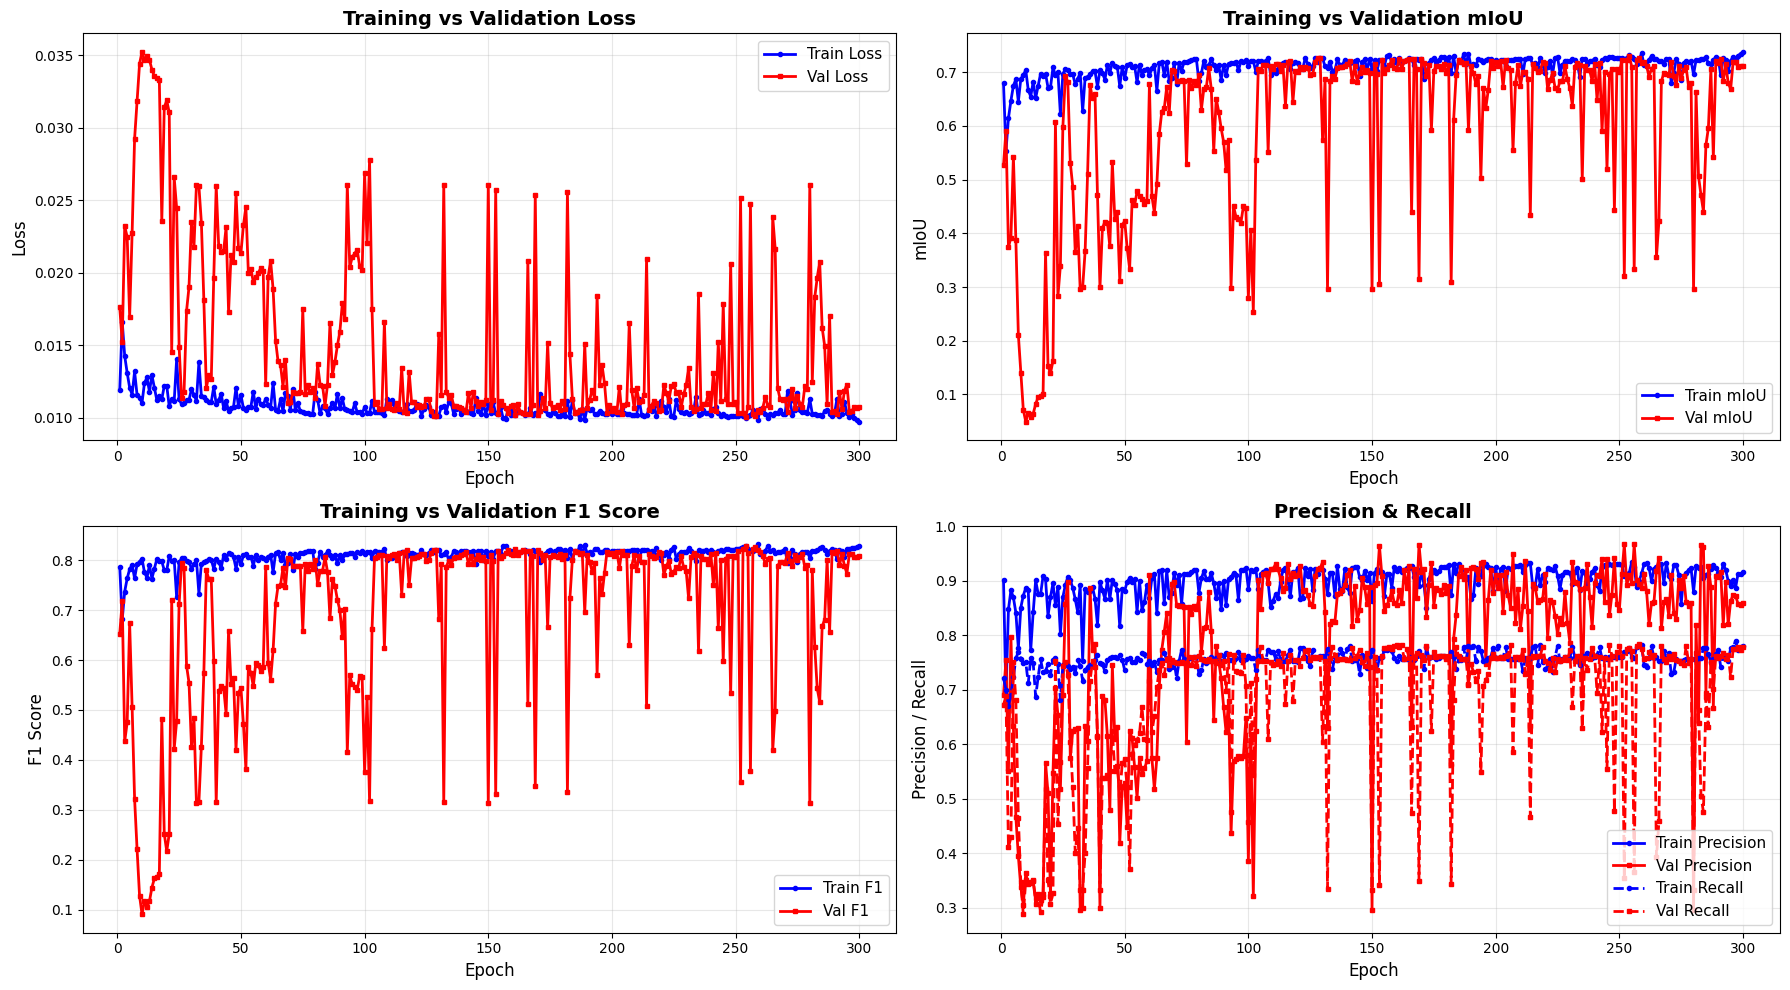


📊 TRAINING ANALYSIS:

  Final Train Loss: 0.00971
  Final Val Loss:   0.01070
  Loss Gap:         0.00099

  Final Train mIoU: 0.73814
  Final Val mIoU:   0.71092
  mIoU Gap:         0.02722

  Final Train F1:   0.82779
  Final Val F1:     0.80758
  F1 Gap:           0.02021

  Best Val Loss:    inf

  ✅ Good generalization!



In [65]:
BEST_LR = 10e-3
BEST_REG = 0

trainer = FCNTrainer(
    model=model,
    train_loader=overfit_loader,      # ← Usa il FULL 640x480!
    val_loader=overfit_loader,
    device=device,
    lr=BEST_LR,                     # ← Dal tuo hyperparameter search
    weight_decay=BEST_REG,          # ← Dal tuo hyperparameter search
    num_epochs=300,
    save_dir='checkpoints',          # ← Directory per salvataggio
    loss_type = 'JaccardLoss'
)

# 3. TRAINING COMPLETO
#start_epoch = trainer.load_last_checkpoint('/kaggle/working/checkpoints')
trainer.train(index_list = index_list)

# 4. Plot curve
trainer.plot_curves()